# Multimodal XAI: Interpreting Vision + Text Fusion for AD Classification

Three methods:
1. **Modality contribution** (gradient x input on fusion MLP)
2. **Brain spatial map** (gradient x activation on ViT patch tokens)
3. **Text token importance** (gradient from fusion logit through ModernBERT)

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# Set working directory to project root
PROJECT_ROOT = '/home/fnp23/python_projects/neuro_interp'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from multimodal.models import MLPFusion
from miccai_vit.model import MICCAIViTClassifier

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Working dir: {os.getcwd()}')

Device: cuda
Working dir: /home/fnp23/python_projects/neuro_interp


## Load models and select 4 test patients

In [2]:
# Load fusion model (archived checkpoint — won't be overwritten by future runs)
fusion = MLPFusion(dropout=0.0).to(device)  # no dropout at inference
ckpt = torch.load('results/multimodal/fusion_model_seed42.pt', map_location=device, weights_only=False)
fusion.load_state_dict(ckpt['model_state_dict'])
fusion.eval()
print(f'Fusion model loaded (test AUROC={ckpt["test_auroc"]:.4f}, seed=42)')

# Load embeddings
all_emb = torch.load('data/embeddings/all_embeddings.pt', map_location='cpu', weights_only=False)

# Get test patients
test_pids = [pid for pid, e in all_emb.items() if e['split'] == 'test']
test_labels = {pid: all_emb[pid]['label'] for pid in test_pids}

# Get fusion predictions on all test patients
test_v = torch.stack([all_emb[pid]['v_cls'] for pid in test_pids]).to(device)
test_t = torch.stack([all_emb[pid]['t_emb'] for pid in test_pids]).to(device)

with torch.no_grad():
    test_out = fusion(test_v, test_t)
    test_probs = torch.softmax(test_out['logits'], dim=1)[:, 1].cpu().numpy()
    test_preds = (test_probs >= 0.5).astype(int)

# Select 4 correctly classified patients: 2 AD, 2 CN
correct_ad = [pid for pid, p, pred in zip(test_pids, test_probs, test_preds) if test_labels[pid] == 1 and pred == 1]
correct_cn = [pid for pid, p, pred in zip(test_pids, test_probs, test_preds) if test_labels[pid] == 0 and pred == 0]

selected = correct_ad[:2] + correct_cn[:2]
print(f'Selected patients: {selected}')
for pid in selected:
    idx = test_pids.index(pid)
    print(f'  PID {pid}: label={test_labels[pid]} ({"AD" if test_labels[pid]==1 else "CN"}), '
          f'prob={test_probs[idx]:.3f}, pred={test_preds[idx]}')

Fusion model loaded (test AUROC=0.8048, seed=42)
Selected patients: [671, 2058, 123, 934]
  PID 671: label=1 (AD), prob=0.953, pred=1
  PID 2058: label=1 (AD), prob=0.972, pred=1
  PID 123: label=0 (CN), prob=0.206, pred=0
  PID 934: label=0 (CN), prob=0.059, pred=0


## Method 1: Modality Contribution (Gradient x Input on Fusion MLP)

In [3]:
modality_contributions = []

for pid in selected:
    fusion.zero_grad()
    
    v_cls = all_emb[pid]['v_cls'].to(device).unsqueeze(0).requires_grad_(True)  # (1, 768)
    t_emb = all_emb[pid]['t_emb'].to(device).unsqueeze(0).requires_grad_(True)  # (1, 768)
    
    out = fusion(v_cls, t_emb)
    
    # Use the PREDICTED class logit (AD=1 for AD patients, CN=0 for CN patients)
    pred_class = out['logits'].argmax(dim=1).item()
    pred_logit = out['logits'][0, pred_class]
    pred_logit.backward()
    
    # Gradient x input attribution
    v_attr = (v_cls.grad * v_cls).abs().sum().item()
    t_attr = (t_emb.grad * t_emb).abs().sum().item()
    total = v_attr + t_attr + 1e-8
    
    v_pct = 100 * v_attr / total
    t_pct = 100 * t_attr / total
    
    label_str = 'AD' if test_labels[pid] == 1 else 'CN'
    pred_str = 'AD' if pred_class == 1 else 'CN'
    
    modality_contributions.append({
        'pid': pid, 'label': test_labels[pid], 'pred_class': pred_class,
        'vision_pct': v_pct, 'text_pct': t_pct,
        'prob': test_probs[test_pids.index(pid)],
    })
    print(f'PID {pid} (true={label_str}, pred={pred_str}): '
          f'Vision={v_pct:.1f}%, Text={t_pct:.1f}%, P(AD)={test_probs[test_pids.index(pid)]:.3f}')

PID 671 (true=AD, pred=AD): Vision=17.3%, Text=82.7%, P(AD)=0.953
PID 2058 (true=AD, pred=AD): Vision=18.3%, Text=81.7%, P(AD)=0.972
PID 123 (true=CN, pred=CN): Vision=12.0%, Text=88.0%, P(AD)=0.206
PID 934 (true=CN, pred=CN): Vision=13.6%, Text=86.4%, P(AD)=0.059


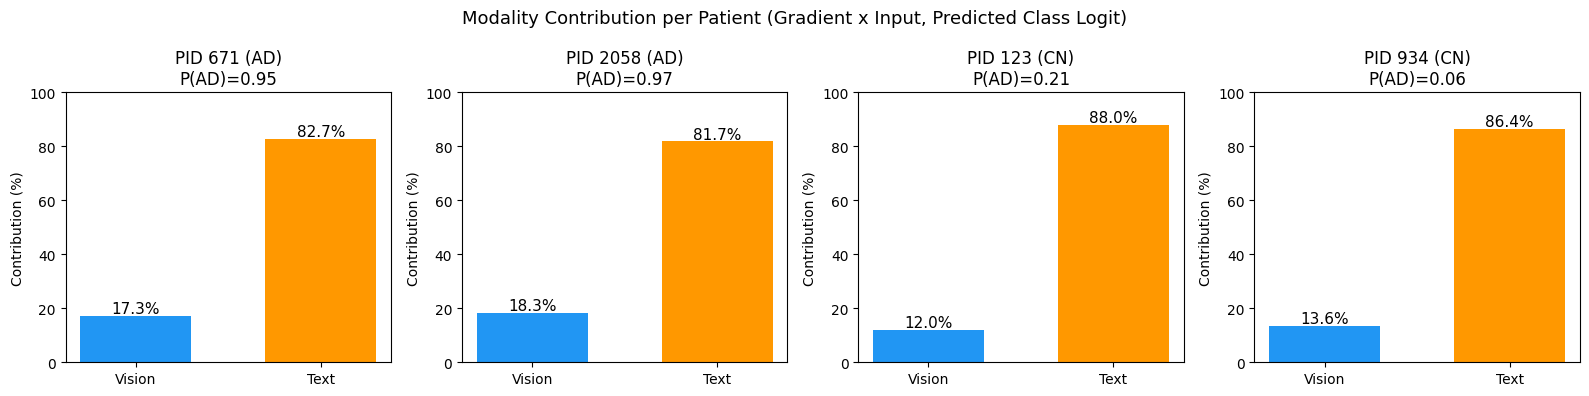

Saved modality contribution plot


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Modality Contribution per Patient (Gradient x Input, Predicted Class Logit)', fontsize=13)

for i, mc in enumerate(modality_contributions):
    ax = axes[i]
    bars = ax.bar(['Vision', 'Text'], [mc['vision_pct'], mc['text_pct']], 
                  color=['#2196F3', '#FF9800'], width=0.6)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Contribution (%)')
    label_str = 'AD' if mc['label'] == 1 else 'CN'
    pred_str = 'AD' if mc['pred_class'] == 1 else 'CN'
    ax.set_title(f'PID {mc["pid"]} ({label_str})\nP(AD)={mc["prob"]:.2f}')
    
    for bar, pct in zip(bars, [mc['vision_pct'], mc['text_pct']]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{pct:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/multimodal/xai_modality_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved modality contribution plot')

## Method 2: Brain Spatial Map (Gradient x Activation on ViT Patch Tokens)

In [5]:
# Load frozen ViT for live inference
vit = MICCAIViTClassifier(n_classes=2).to(device)
vit_ckpt = torch.load('results/miccai_vit_t1/best_model.pt', map_location=device, weights_only=False)
vit.load_state_dict(vit_ckpt['model_state_dict'])
vit.eval()
print('ViT loaded')

ViT loaded


In [6]:
spatial_maps = {}

for pid in selected:
    fusion.zero_grad()
    vit.zero_grad()
    
    # Load T1 volume
    arr = np.load(f'data/T1_preprocessed_miccai/{pid}.npy')  # (1, 128, 128, 128)
    img = torch.from_numpy(arr).unsqueeze(0).to(device)  # (1, 1, 128, 128, 128)
    
    with torch.enable_grad():
        # Manual forward to intercept hidden_states[-2]
        B = img.shape[0]
        x = vit.patch_embed(img)
        cls_tokens = vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + vit.pos_embed
        x = vit.pos_drop(x)
        
        # Run through all blocks, capture second-to-last output
        for i, blk in enumerate(vit.blocks):
            if i == len(vit.blocks) - 1:
                x_pre_last = x.detach().requires_grad_(True)
                x = blk(x_pre_last)
            else:
                x = blk(x)
        
        x = vit.norm(x)
        vision_cls = x[:, 0]  # CLS token (768,)
        
        # Get text embedding (cached, no grad needed)
        t_emb = all_emb[pid]['t_emb'].to(device).unsqueeze(0)
        
        # Forward through fusion MLP
        out = fusion(vision_cls, t_emb)
        
        # Use predicted class logit
        pred_class = out['logits'].argmax(dim=1).item()
        out['logits'][0, pred_class].backward()
    
    # Gradient x activation importance on patch tokens
    patch_grad = x_pre_last.grad[:, 1:, :]  # exclude CLS, (1, 512, 768)
    patch_tokens = x_pre_last.detach()[:, 1:, :]  # (1, 512, 768)
    importance = (patch_grad * patch_tokens).abs().sum(dim=-1).squeeze(0).cpu().numpy()  # (512,)
    
    # Reshape to 8x8x8 spatial grid and upsample to 128^3
    importance_3d = importance.reshape(8, 8, 8)
    importance_128 = zoom(importance_3d, 128 / 8, order=1)
    
    # Normalize to [0, 1]
    importance_128 = (importance_128 - importance_128.min()) / (importance_128.max() - importance_128.min() + 1e-8)
    
    spatial_maps[pid] = importance_128
    label_str = 'AD' if test_labels[pid] == 1 else 'CN'
    print(f'PID {pid} ({label_str}): importance range [{importance.min():.4f}, {importance.max():.4f}]')

PID 671 (AD): importance range [0.0000, 0.5057]
PID 2058 (AD): importance range [0.0000, 0.3609]
PID 123 (CN): importance range [0.0000, 0.2001]
PID 934 (CN): importance range [0.0000, 0.6456]


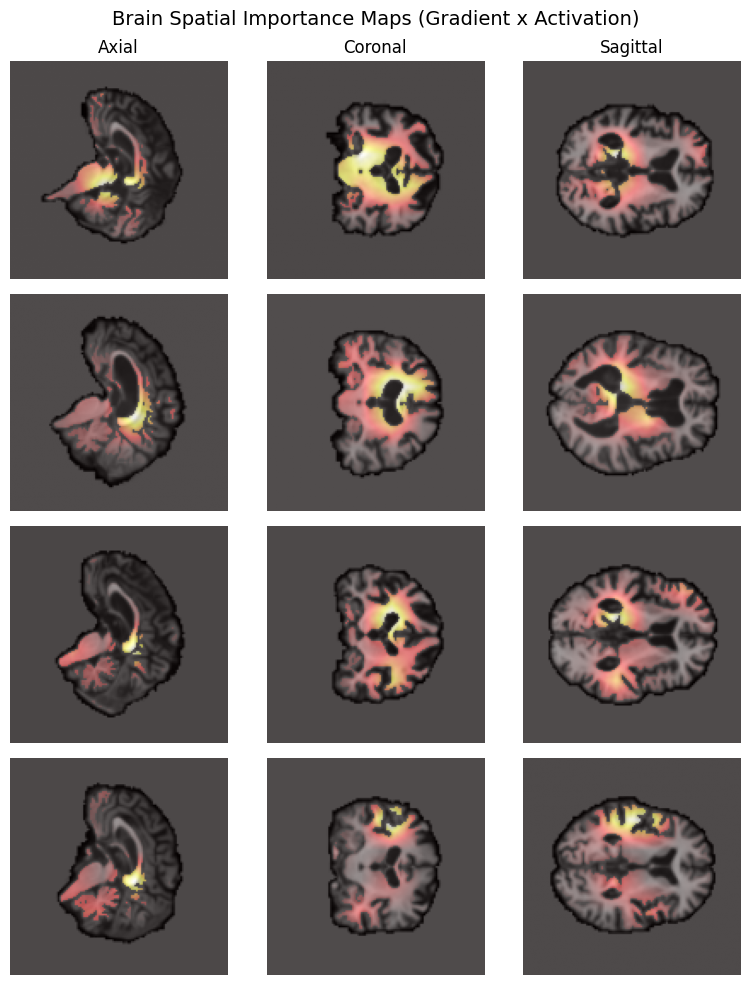

Saved brain spatial maps


In [7]:
fig, axes = plt.subplots(4, 3, figsize=(8, 10))
fig.suptitle('Brain Spatial Importance Maps (Gradient x Activation)', fontsize=14)

for i, pid in enumerate(selected):
    t1 = np.load(f'data/T1_preprocessed_miccai/{pid}.npy')[0]  # (128, 128, 128)
    heatmap = spatial_maps[pid]
    nonzero = t1[t1 > 0]
    thr = np.percentile(nonzero, 20)
    brain_mask = (t1 > thr).astype(np.float32)
    heatmap = heatmap * brain_mask
    label_str = 'AD' if test_labels[pid] == 1 else 'CN'
    mid = 64
    
    # Axial
    axes[i, 0].imshow(t1[mid, :, :], cmap='gray', origin='lower')
    axes[i, 0].imshow(heatmap[mid, :, :], cmap='hot', alpha=0.4, origin='lower')
    axes[i, 0].set_title(f'Axial' if i == 0 else '')
    axes[i, 0].set_ylabel(f'PID {pid} ({label_str})', fontsize=11)
    axes[i, 0].axis('off')
    
    # Coronal
    axes[i, 1].imshow(t1[:, mid, :], cmap='gray', origin='lower')
    axes[i, 1].imshow(heatmap[:, mid, :], cmap='hot', alpha=0.4, origin='lower')
    axes[i, 1].set_title(f'Coronal' if i == 0 else '')
    axes[i, 1].axis('off')
    
    # Sagittal
    axes[i, 2].imshow(t1[:, :, mid], cmap='gray', origin='lower')
    axes[i, 2].imshow(heatmap[:, :, mid], cmap='hot', alpha=0.4, origin='lower')
    axes[i, 2].set_title(f'Sagittal' if i == 0 else '')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('results/multimodal/xai_brain_spatial_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved brain spatial maps')

## Method 3: Text Token Importance (Gradient from Fusion Logit through ModernBERT)

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import csv

# Load ModernBERT
text_model = AutoModelForSequenceClassification.from_pretrained(
    'llm_checkpoints/modernbert_adni_finetuned'
).to(device)
text_model.eval()
tokenizer = AutoTokenizer.from_pretrained('answerdotai/ModernBERT-base')
print('ModernBERT loaded')

# Load text for selected patients
text_by_pid = {}
for csv_path in ['data/project_1_3_data/IID/ADNI_binary_training.csv',
                 'data/project_1_3_data/IID/ADNI_binary_testing.csv']:
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            text_by_pid[int(row['Patient_ID'])] = row['Generated_Text']
print(f'Loaded text for {len(text_by_pid)} patients')

/home/fnp23/python_projects/neuro_interp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModernBERT loaded
Loaded text for 2284 patients


In [9]:
token_attributions = {}

for pid in selected:
    fusion.zero_grad()
    text_model.zero_grad()
    
    text = text_by_pid[pid]
    inputs = tokenizer(text, return_tensors='pt', max_length=512, padding='max_length', truncation=True)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    v_cls = all_emb[pid]['v_cls'].to(device).unsqueeze(0)
    
    # Get base embeddings from frozen ModernBERT
    with torch.no_grad():
        base_emb = text_model.model.embeddings(input_ids)
    
    # Create differentiable copy
    diff_emb = base_emb.clone().detach().requires_grad_(True)
    
    # Hook to replace embedding output with our differentiable version
    def replace_hook(module, input, output):
        return diff_emb
    
    hook = text_model.model.embeddings.register_forward_hook(replace_hook)
    out_text = text_model.model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    hook.remove()
    
    # Mean pool last hidden state (matches classifier_pooling="mean")
    h = out_text.last_hidden_state
    mask = attention_mask.unsqueeze(-1).float()
    text_emb = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
    
    # Forward through fusion MLP
    out = fusion(v_cls.detach(), text_emb)
    
    # Use predicted class logit — gradients flow from fusion logit through ModernBERT
    pred_class = out['logits'].argmax(dim=1).item()
    out['logits'][0, pred_class].backward()
    
    # Token importance: gradient x input, L2 norm per token
    token_imp = (diff_emb.grad * diff_emb).detach().norm(dim=-1).squeeze(0).cpu().numpy()
    real_len = int(attention_mask.sum().item())
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0, :real_len].cpu())
    token_imp = token_imp[:real_len]
    
    # Filter out special tokens for display
    display_pairs = [(tok, imp) for tok, imp in zip(tokens, token_imp) 
                     if tok not in ('[CLS]', '[SEP]', '[PAD]')]
    display_pairs.sort(key=lambda x: x[1], reverse=True)
    top_10 = display_pairs[:10]
    
    token_attributions[pid] = {
        'tokens': tokens,
        'importance': token_imp,
        'top_tokens': top_10,
    }
    
    label_str = 'AD' if test_labels[pid] == 1 else 'CN'
    pred_str = 'AD' if pred_class == 1 else 'CN'
    print(f'\nPID {pid} (true={label_str}, pred={pred_str}): Top-10 tokens:')
    for tok, imp in top_10:
        print(f'  {tok:25s} importance={imp:.4f}')


PID 671 (true=AD, pred=AD): Top-10 tokens:
  Ġ8                        importance=0.0057
  Ġ7                        importance=0.0037
  Ġ7                        importance=0.0037
  ĠTotal                    importance=0.0028
  Ġ3                        importance=0.0026
  ĠTime                     importance=0.0021
  Ġ6                        importance=0.0021
  0                         importance=0.0021
  ?                         importance=0.0021
  ĠAnimals                  importance=0.0020

PID 2058 (true=AD, pred=AD): Top-10 tokens:
  Ġ8                        importance=0.0112
  Ġ7                        importance=0.0067
  ĠTotal                    importance=0.0050
  Ġ6                        importance=0.0042
  .                         importance=0.0041
  Ġ6                        importance=0.0038
  Ġ2                        importance=0.0038
  Ġ4                        importance=0.0037
  Ġwere                     importance=0.0036
  Ġafter                    importanc

In [10]:
# Show top tokens in their original text context
from IPython.display import display, HTML

for pid in selected:
    ta = token_attributions[pid]
    tokens = ta['tokens']
    importance = ta['importance']
    label_str = 'AD' if test_labels[pid] == 1 else 'CN'
    prob = test_probs[test_pids.index(pid)]
    
    # Normalize importance to [0, 1] for coloring
    imp_norm = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)
    
    # Build highlighted HTML text inside a white card so the colors remain visible in dark notebook themes
    html_parts = [
        f'<div style="background:#ffffff; color:#111111; padding:16px; border:1px solid #dddddd; border-radius:8px; margin:12px 0;">'
        f'<h4 style="margin:0 0 12px 0; color:#111111;">PID {pid} ({label_str}, P(AD)={prob:.2f})</h4>'
        f'<p style="font-family:monospace; line-height:1.8; color:#111111; margin:0;">'
    ]
    
    threshold_90 = np.percentile(imp_norm, 90)  # top 10% highlighted
    threshold_75 = np.percentile(imp_norm, 75)  # top 25% lightly highlighted
    
    for tok, imp_n in zip(tokens, imp_norm):
        # Clean up token display
        display_tok = tok.replace('Ġ', ' ').replace('##', '')
        if tok in ('[CLS]', '[SEP]', '[PAD]'):
            continue
        
        if imp_n >= threshold_90:
            # Strong highlight — red background
            html_parts.append(f'<span style="background-color:rgba(255,0,0,{min(imp_n*1.5, 0.8)}); '
                            f'padding:2px; border-radius:3px; font-weight:bold;" '
                            f'title="importance={importance[tokens.index(tok)]:.4f}">'
                            f'{display_tok}</span>')
        elif imp_n >= threshold_75:
            # Light highlight — orange
            html_parts.append(f'<span style="background-color:rgba(255,165,0,{min(imp_n, 0.4)}); '
                            f'padding:1px; border-radius:2px;" '
                            f'title="importance={importance[tokens.index(tok)]:.4f}">'
                            f'{display_tok}</span>')
        else:
            html_parts.append(f'<span title="importance={importance[tokens.index(tok)]:.4f}">{display_tok}</span>')
    
    html_parts.append('</p></div>')
    display(HTML(''.join(html_parts)))
    print()

## Summary

In [32]:
print('=' * 60)
print('XAI SUMMARY')
print('=' * 60)

print('\nModality Contributions:')
for mc in modality_contributions:
    label = 'AD' if mc['label'] == 1 else 'CN'
    print(f"  PID {mc['pid']} ({label}): Vision={mc['vision_pct']:.1f}%, Text={mc['text_pct']:.1f}%")

mean_v = np.mean([mc['vision_pct'] for mc in modality_contributions])
mean_t = np.mean([mc['text_pct'] for mc in modality_contributions])
print(f'\n  Average: Vision={mean_v:.1f}%, Text={mean_t:.1f}%')
print(f'\nSaved figures to results/multimodal/')

XAI SUMMARY

Modality Contributions:
  PID 671 (AD): Vision=17.3%, Text=82.7%
  PID 2058 (AD): Vision=18.3%, Text=81.7%
  PID 123 (CN): Vision=12.0%, Text=88.0%
  PID 934 (CN): Vision=13.6%, Text=86.4%

  Average: Vision=15.3%, Text=84.7%

Saved figures to results/multimodal/
